In [1]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt

df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['bruehler_straße'].sum())
header = 'bruehler_straße'

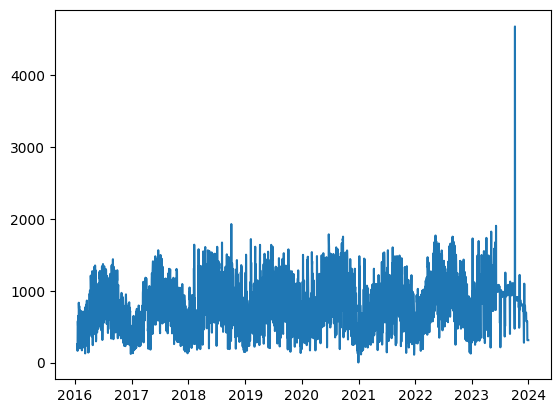

In [2]:
plt.plot(df[header])

In [3]:
df.index = pd.to_datetime(df.index)
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [4]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

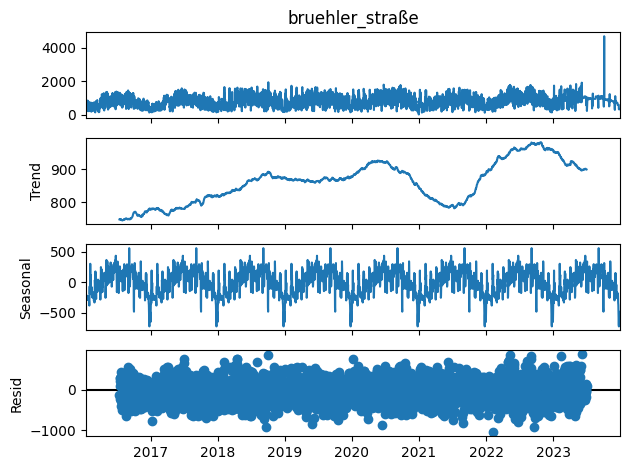

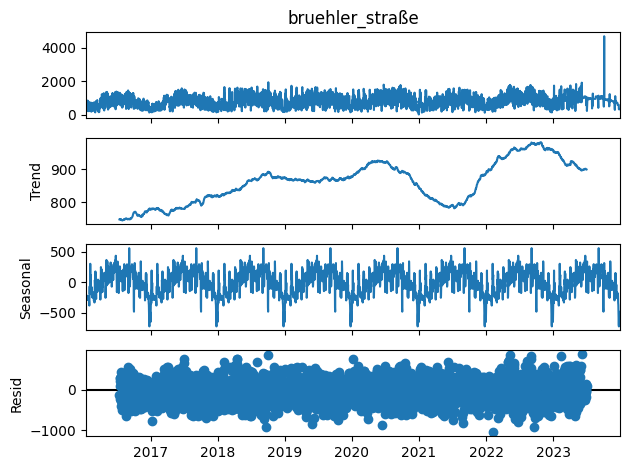

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df[header], period=365)
decomposition.plot()

In [6]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -4.2927
p-value = 0.0005


In [7]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [8]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df) * 0.9)
df_train = df.iloc[:end_train]
df_test = df.iloc[end_train:]

In [9]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=365)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

C:\Users\caddowallace\AppData\Local\Temp\ipykernel_14512\3224188387.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=365)


Test statistic = -5.7196
P-value = 0.0000


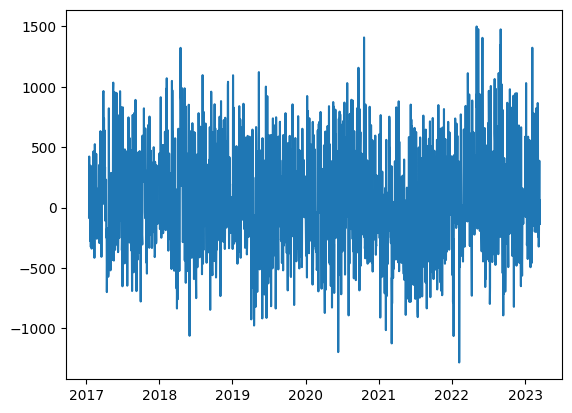

In [10]:
plt.plot(df_train.loc[:,'differences'] )

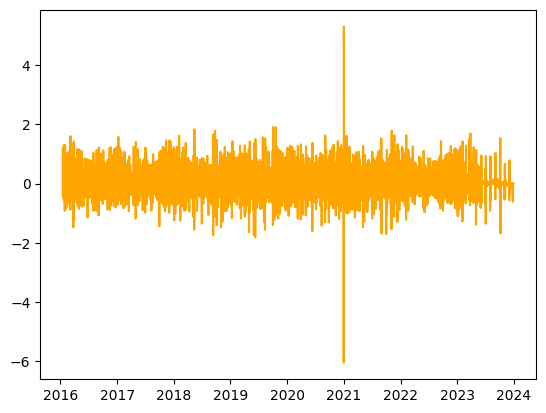

In [11]:
df['first_logged_diff'] = df['log'].diff().dropna()

plt.plot(df['first_logged_diff'], color='orange')
plt.show()

In [12]:
result = adfuller(df['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -18.4874
P-value = 0.0000


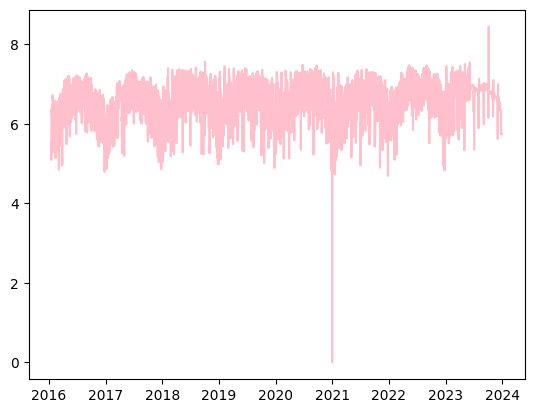

In [13]:
plt.plot(df['log'], color='pink')

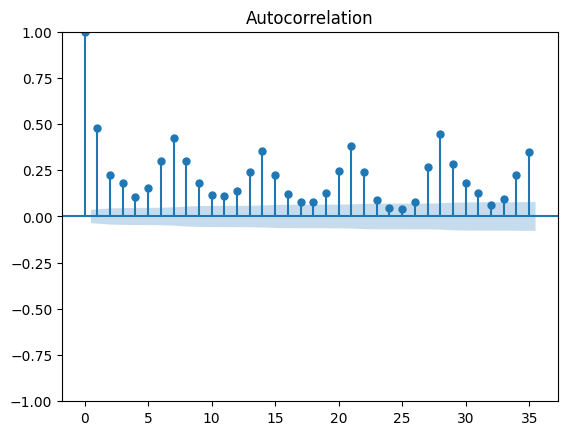

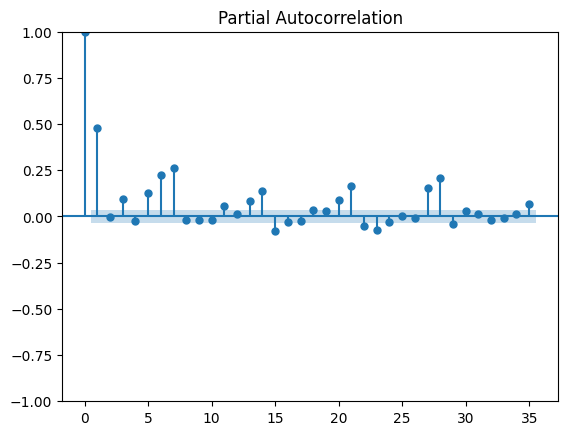

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df[header])
plot_pacf(df[header])
plt.show()

In [15]:
df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')
df_test = df_test.asfreq('D')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



In [16]:
def ma_arima():
    for i in range(1, 3):
        p, d, q = i, 0, 0

        arima = SARIMAX(df_train['log'], order=(p, d, q))
        result = arima.fit()
        #print(result.summary())
        print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
        # Update des DataFrames
        df['differences'] = df_train['differences']
        model = SARIMAX(df['log'], order=(p, d, q))
        result_new = model.filter(result.params)

        # Vorhersage
        predicted = result_new.predict(start=start_date, end=future_date)
        tmp = pd.DataFrame(predicted)
        tmp['crossings'] = tmp['predicted_mean']
        tmp.index = tmp.index.date
        tmp['crossings'] =  np.exp(tmp['crossings'])
        tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

        # Mergen der Daten
        df_r = pd.concat([df_train, tmp], axis=1)
        #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

        df_r[header] = df_r[header].fillna(df_r['crossings'])
        df_r = pd.DataFrame(df_r)
        df_r.index = pd.to_datetime(df_r.index)

        # Plotten
        plt.title('MA, Ordnung = {:.0f}'.format(i))
        plt.plot(df_r.loc[start_date:future_date, header],
             color='yellow', label='predicted')
        plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
        plt.legend()
        plt.show()

        y_pred_simple = df_test[header].iloc[:-1]
        y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
        y_pred_simple = y_pred_simple.sort_index().tolist()

        df_test.loc[:,'intervals'] = (df_test[header] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
        df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
        df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
        df_test.loc[:,'simple_predict'] = y_pred_simple

        greater = df_test[df_test['group'] == '> 10']
        mape_arima = []
        mape_simple = []

        for name, group in greater.groupby('intervals'):
            mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
            mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

        mae_arima = np.mean(np.abs(df_test[header] - predicted))
        mse_arima = np.mean(np.square(df_test[header] - predicted))
        mape_arima = sum(mape_arima)/len(mape_arima)
        mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
        mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
        mape_simple = sum(mape_simple)/len(mape_simple)

        print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
        print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
        print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

Log Likelihood: -2154.8504, AIC: 4313.7008


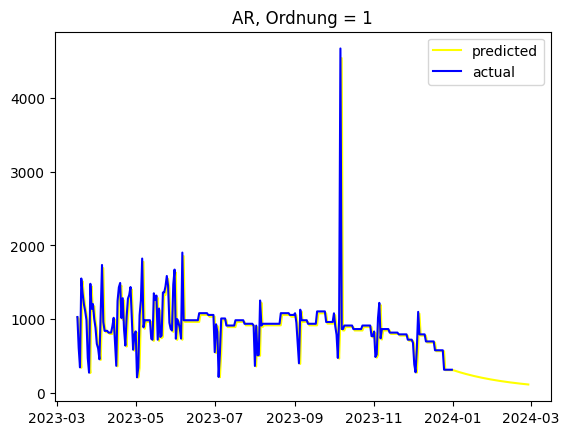

mean absolute error (mae): ARIMA: 913.9571, simple: 155.5897
mean squared error (mse): ARIMA: 952481.0565, simple: 166122.2724
mean absolute percentage error (mape): ARIMA: 0.1933, simple: 0.1870
Log Likelihood: -2053.8661, AIC: 4113.7321


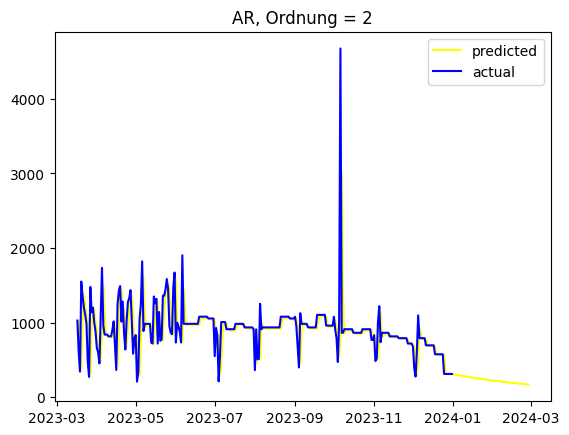

mean absolute error (mae): ARIMA: 913.9494, simple: 155.5897
mean squared error (mse): ARIMA: 952485.9752, simple: 166122.2724
mean absolute percentage error (mape): ARIMA: 0.1910, simple: 0.1870
Log Likelihood: -1939.8322, AIC: 3887.6644


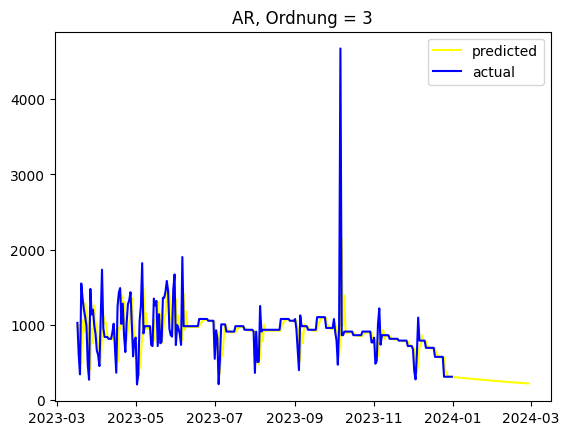

mean absolute error (mae): ARIMA: 913.9434, simple: 155.5897
mean squared error (mse): ARIMA: 952478.5810, simple: 166122.2724
mean absolute percentage error (mape): ARIMA: 0.1908, simple: 0.1870
Log Likelihood: -1913.0556, AIC: 3836.1113


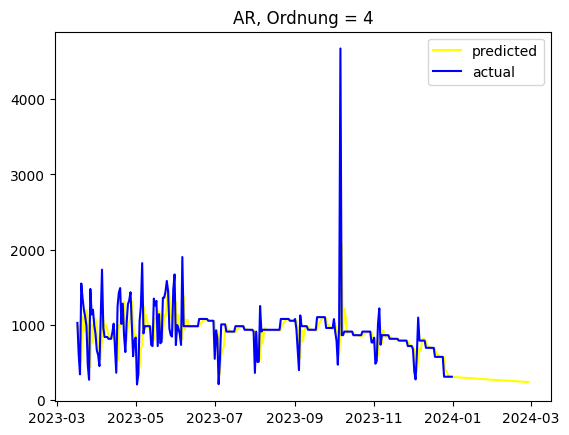

mean absolute error (mae): ARIMA: 913.9407, simple: 155.5897
mean squared error (mse): ARIMA: 952476.3433, simple: 166122.2724
mean absolute percentage error (mape): ARIMA: 0.1906, simple: 0.1870


In [17]:
for i in range(1, 5):
    p, d, q = i, 0, 0

    arima = SARIMAX(df_train['log'], order=(p, d, q))
    result = arima.fit()
    #print(result.summary())
    print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['log'], order=(p, d, q))
    result_new = model.filter(result.params)

    # Vorhersage
    predicted = result_new.predict(start=start_date, end=future_date)
    tmp = pd.DataFrame(predicted)
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    tmp['crossings'] =  np.exp(tmp['crossings'])
    tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

    # Mergen der Daten
    df_r = pd.concat([df_train, tmp], axis=1)
    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

    df_r[header] = df_r[header].fillna(df_r['crossings'])
    df_r = pd.DataFrame(df_r)
    df_r.index = pd.to_datetime(df_r.index)

    # Plotten
    plt.title('AR, Ordnung = {:.0f}'.format(i))
    plt.plot(df_r.loc[start_date:future_date, header],
         color='yellow', label='predicted')
    plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
    plt.legend()
    plt.show()

    y_pred_simple = df_test[header].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()

    df_test.loc[:,'intervals'] = (df_test[header] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
    df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
    df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
    df_test.loc[:,'simple_predict'] = y_pred_simple

    greater = df_test[df_test['group'] == '> 10']
    mape_arima = []
    mape_simple = []

    for name, group in greater.groupby('intervals'):
        mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
        mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

    mae_arima = np.mean(np.abs(df_test[header] - predicted))
    mse_arima = np.mean(np.square(df_test[header] - predicted))
    mape_arima = sum(mape_arima)/len(mape_arima)
    mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
    mape_simple = sum(mape_simple)/len(mape_simple)

    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
    print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

In [18]:
df_r

,bruehler_straße,scaled,log,differences,predicted_mean,crossings
2016-01-16,256.000000,255.054355,5.541477,NaN,NaN,NaN
2016-01-17,164.000000,163.034667,5.093963,NaN,NaN,NaN
2016-01-18,559.000000,558.119195,6.324573,NaN,NaN,NaN
2016-01-19,581.000000,580.123903,6.363242,NaN,NaN,NaN
2016-01-20,513.000000,512.109352,6.238538,NaN,NaN,NaN
...,...,...,...,...,...,...
2024-02-24,245.704508,NaN,NaN,NaN,5.500264,245.704508
2024-02-25,244.677979,NaN,NaN,NaN,5.496061,244.677979
2024-02-26,243.656536,NaN,NaN,NaN,5.491860,243.656536
2024-02-27,242.640150,NaN,NaN,NaN,5.487663,242.640150


Log Likelihood: -2154.8504, AIC: 4313.7008


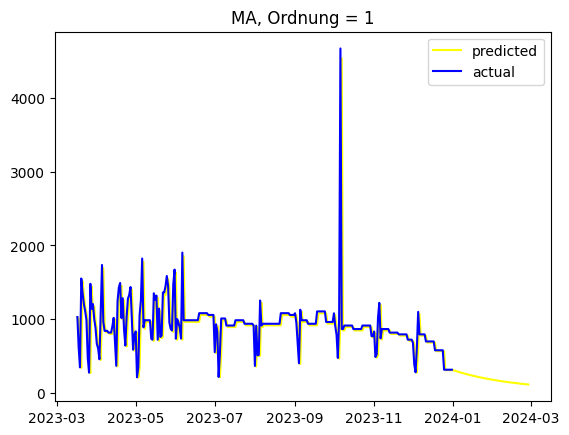

mean absolute error (mae): ARIMA: 913.9571, simple: 155.5897
mean squared error (mse): ARIMA: 952481.0565, simple: 166122.2724
mean absolute percentage error (mape): ARIMA: 0.1933, simple: 0.1870
Log Likelihood: -2053.8661, AIC: 4113.7321


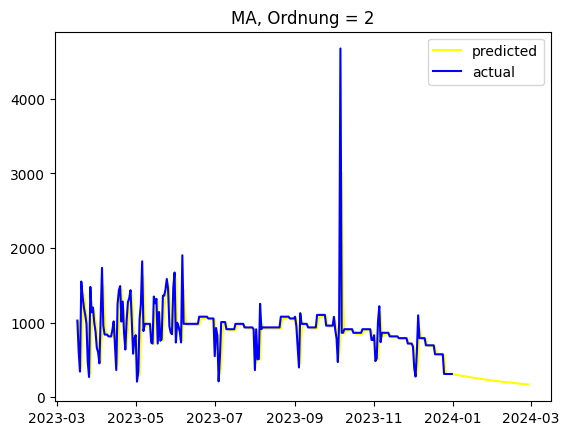

mean absolute error (mae): ARIMA: 913.9494, simple: 155.5897
mean squared error (mse): ARIMA: 952485.9752, simple: 166122.2724
mean absolute percentage error (mape): ARIMA: 0.1910, simple: 0.1870


In [19]:
ma_arima()

Seasonal ARIMA

In [20]:
df_unstack = df[[header]]
df_unstack = df_unstack.set_index([df.index.year, df.index.month])
df_unstack.index.rename(['year', 'month'], inplace=True)
df_unstack = df_unstack.groupby(['year', 'month'])[header].apply(lambda x : x.astype(int).sum())
df_unstack = df_unstack.unstack(['month'])
df_unstack

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2016,8304,14704,16553,25046,26992,27757,29613,29314,31948,21358,19176,16633
2017,13990,14895,23436,23016,29670,31631,29711,27433,26836,26335,22038,15630
2018,18982,17830,21279,30568,30740,32520,30581,29346,29167,28013,26622,20105
2019,19550,23804,23838,25277,31068,31052,29302,29941,28028,27837,25136,20663
2020,23090,20993,24808,26740,31517,33161,34343,33103,34081,29783,25448,18676
2021,18347,20443,20701,24330,22443,27680,25790,29228,31462,25436,22948,20303
2022,19611,18930,30647,27402,38110,33049,30694,39589,32882,30313,29584,18052
2023,21723,23781,30237,28850,33095,30851,27825,29346,29189,31000,24128,18089


In [21]:
#Mittelwertbereinigung
df['days_noyear'] = pd.to_datetime(df.index).strftime('%m-%d')
df['day_mean'] = df.groupby('days_noyear')['log'].transform('mean')
df['cleaned_by_mean'] = df['log'] - df['day_mean']
display(df)

,bruehler_straße,scaled,log,first_logged_diff,differences,days_noyear,day_mean,cleaned_by_mean
2016-01-16,256,255.054355,5.541477,NaN,NaN,01-16,6.289341,-0.747864
2016-01-17,164,163.034667,5.093963,-0.447514,NaN,01-17,6.195467,-1.101504
2016-01-18,559,558.119195,6.324573,1.230610,NaN,01-18,6.447677,-0.123104
2016-01-19,581,580.123903,6.363242,0.038669,NaN,01-19,6.300355,0.062886
2016-01-20,513,512.109352,6.238538,-0.124704,NaN,01-20,6.295775,-0.057237
...,...,...,...,...,...,...,...,...
2023-12-27,312,311.066339,5.740006,0.000000,NaN,12-27,5.877537,-0.137530
2023-12-28,312,311.066339,5.740006,0.000000,NaN,12-28,5.957908,-0.217902
2023-12-29,312,311.066339,5.740006,0.000000,NaN,12-29,5.876334,-0.136328
2023-12-30,312,311.066339,5.740006,0.000000,NaN,12-30,5.910019,-0.170013


In [22]:
df['weekday'] = df.index.dayofweek  # 0 = Montag, 6 = Sonntag
weekly_pattern = df.groupby('weekday')[header].mean()
print(weekly_pattern)

weekday
0    939.592771
1    973.689157
2    977.556627
3    944.202410
4    913.154217
5    685.605769
6    551.408654
Name: bruehler_straße, dtype: float64


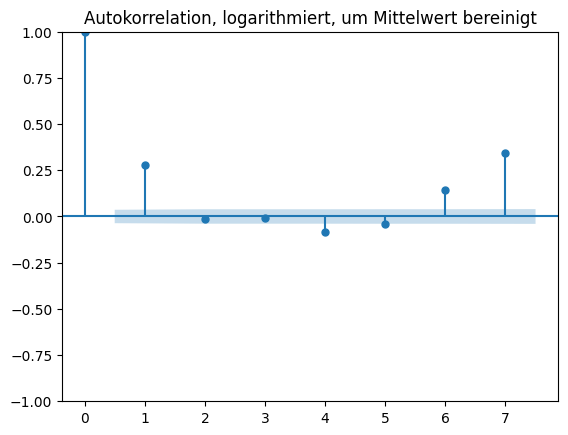

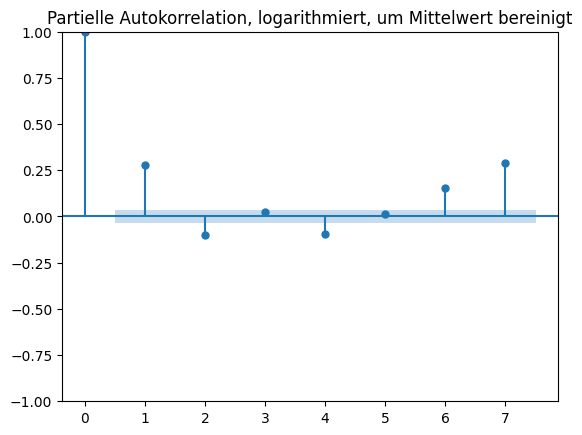

In [23]:
lags  = 7
plot_acf(df['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()
#für Order-Ebene, Lag 1 signifikant

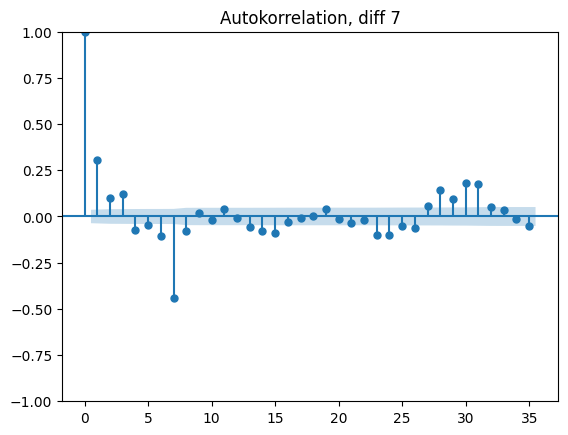

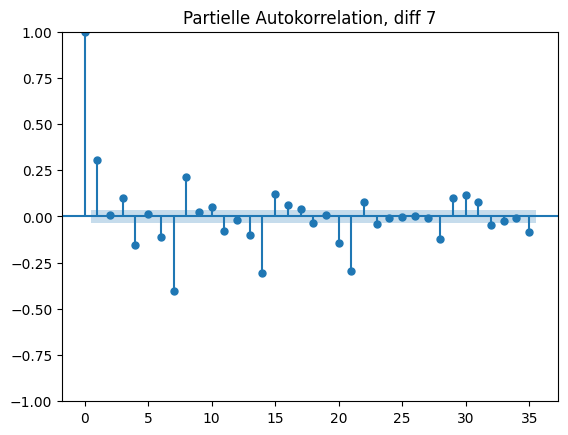

In [24]:
diffs = df[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [25]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df) * 0.8)
df_train_seas = df.iloc[:end_train]
df_test_seas = df.iloc[end_train:]

seasonal = 7
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,7) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))

ARIMA (0,0,0)x(0,1,0,7) LL -2051.2782, AIC: 4104.5565
ARIMA (0,1,0)x(0,1,0,7) LL -2422.0188, AIC: 4846.0376
ARIMA (1,0,0)x(0,1,1,7) LL -1263.0075, AIC: 2532.0151
ARIMA (1,0,0)x(0,1,2,7) LL -1259.8398, AIC: 2527.6796
ARIMA (1,1,0)x(0,1,2,7) LL -1447.3932, AIC: 2902.7863
ARIMA (0,0,1)x(0,1,2,7) LL -1313.3664, AIC: 2634.7328
ARIMA (0,1,1)x(0,1,2,7) LL -1261.9550, AIC: 2531.9100
ARIMA (0,1,1)x(2,1,0,7) LL -1622.8761, AIC: 3253.7522


In [26]:
print(result4.summary())

                                       SARIMAX Results                                        
Dep. Variable:                                    log   No. Observations:                 2326
Model:             SARIMAX(1, 0, 0)x(0, 1, [1, 2], 7)   Log Likelihood               -1259.840
Date:                                Sun, 09 Feb 2025   AIC                           2527.680
Time:                                        22:36:37   BIC                           2550.675
Sample:                                    01-16-2016   HQIC                          2536.060
                                         - 05-29-2022                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4763      0.011     44.479      0.000       0.455       0.497
ma.

In [27]:
results_final = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
y_pred_no_update = results_final.predict(start='2022-05-30', end='2024-12-31')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)


            predicted_mean    unlogged  new_predict
2022-05-30        6.817341  913.552194   914.356954
2022-05-31        6.835323  930.129138   930.930351
2022-06-01        6.857957  951.421360   952.218018
2022-06-02        6.719629  828.510397   829.333352
2022-06-03        6.727923  835.410172   836.231651
...                    ...         ...          ...
2024-12-27        6.720309  829.073676   829.896510
2024-12-28        6.447477  631.108259   631.973447
2024-12-29        6.150955  469.165437   470.065273
2024-12-30        6.794534  892.952986   893.762153
2024-12-31        6.825312  920.863490   921.666685

[947 rows x 3 columns]


Text(0.5, 1.0, 'Prognose')

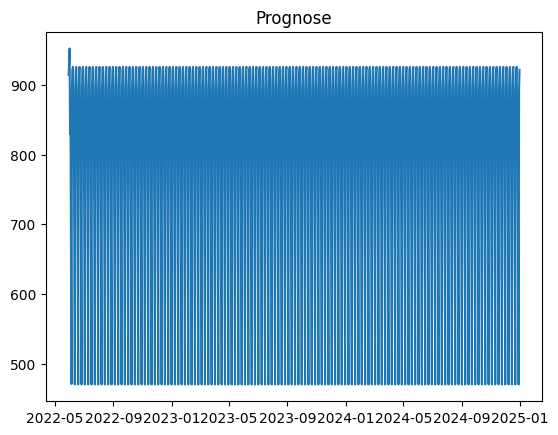

In [28]:
plt.plot(y_pred_no_update['new_predict'])
plt.title('Prognose')

Text(0.5, 1.0, 'tatsächliche Daten')

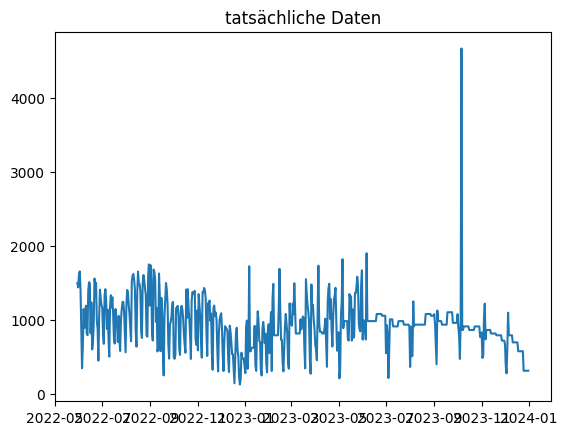

In [29]:
plt.plot(df_test_seas[header])
plt.title('tatsächliche Daten')

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal), freq='D')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal), freq='D')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2022-05-30', end='2024-12-31')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])
tmp

,predicted_mean,unlogged,final_data
2022-05-30,6.817341,913.552194,914.356954
2022-05-31,6.835323,930.129138,930.930351
2022-06-01,6.857957,951.421360,952.218018
2022-06-02,6.719629,828.510397,829.333352
2022-06-03,6.727923,835.410172,836.231651
...,...,...,...
2024-12-27,6.720309,829.073676,829.896510
2024-12-28,6.447477,631.108259,631.973447
2024-12-29,6.150955,469.165437,470.065273
2024-12-30,6.794534,892.952986,893.762153


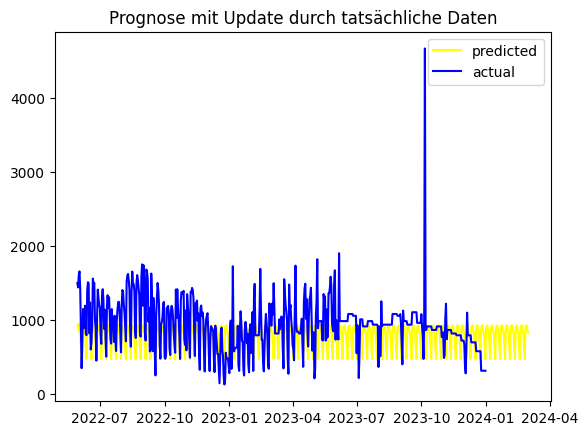

In [31]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2022-05-30'
end_date = '2024-03-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [32]:
mape_bound = 100

df_test_seas.loc[:,'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:,'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-31', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-31', header]))
mape_arima = sum(mape_arima)/len(mape_arima)


print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 263.5266
mean squared error (mse): ARIMA: 133143.5233
mean absolute percentage error (mape): ARIMA: 0.3153


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_14512\1728239483.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:,'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_14512\1728239483.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:,'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_1

Monatlich


In [33]:
df_month = df
df_month.set_index([df_month.index.year, df_month.index.month])
df_month['month'] = df_month.index.month
df_month['year'] = df_month.index.year
df_month = df_month.groupby(['year', 'month']).sum().reset_index()
monthly_pattern = df_month.groupby('month')[header].mean()
print(monthly_pattern)

month
1     17949.625
2     19422.500
3     23937.375
4     26403.625
5     30454.375
6     30962.625
7     29732.375
8     30912.500
9     30449.125
10    27509.375
11    24385.000
12    18518.875
Name: bruehler_straße, dtype: float64


In [34]:
df_month.index

RangeIndex(start=0, stop=96, step=1)

In [35]:
df_month['year-month'] = df_month['year'].astype(str) + '-' + df_month['month'].astype(str).str.zfill(2)
tmp = pd.DataFrame()
tmp['year-month'] =  df_month['year-month']
tmp[header] = df_month[header]
df_month = tmp

In [36]:
df_month['year-month'] = pd.to_datetime(df_month['year-month'])
df_month.index = df_month['year-month']
df_month

,year-month,bruehler_straße
year-month,,
2016-01-01,2016-01-01,8304
2016-02-01,2016-02-01,14704
2016-03-01,2016-03-01,16553
2016-04-01,2016-04-01,25046
2016-05-01,2016-05-01,26992
...,...,...
2023-08-01,2023-08-01,29346
2023-09-01,2023-09-01,29189
2023-10-01,2023-10-01,31000


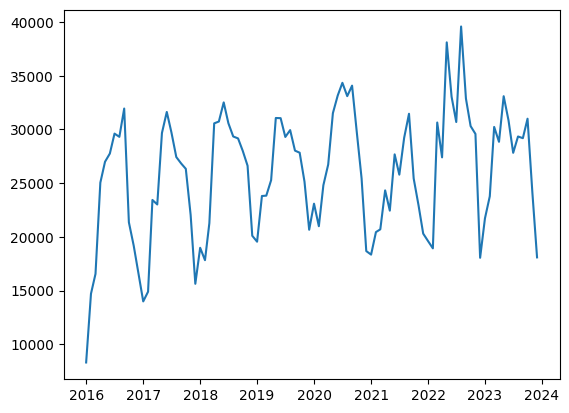

In [37]:
plt.plot(df_month[header])

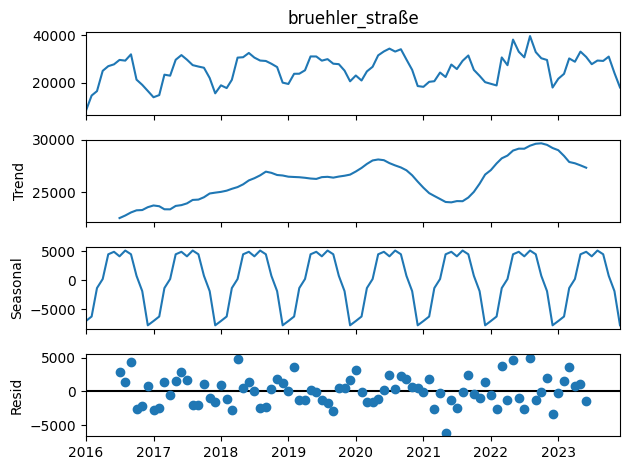

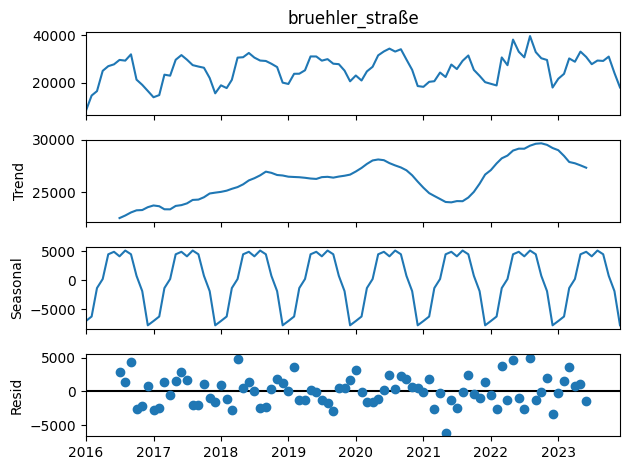

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_month[header], period=12)
decomposition.plot()

In [39]:
result = adfuller(df_month[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -2.1009
p-value = 0.2441


In [40]:
maximum = max(df_month[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df_month[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df_month['scaled'] = scaled_data
df_month['log'] = np.log(df_month['scaled'])
df_month

,year-month,bruehler_straße,scaled,log
year-month,,,,
2016-01-01,2016-01-01,8304,1.000000,0.000000
2016-02-01,2016-02-01,14704,8099.552022,8.999564
2016-03-01,2016-03-01,16553,10439.274317,9.253330
2016-04-01,2016-04-01,25046,21186.305929,9.961110
2016-05-01,2016-05-01,26992,23648.771903,10.071066
...,...,...,...,...
2023-08-01,2023-08-01,29346,26627.520569,10.189701
2023-09-01,2023-09-01,29189,26428.852965,10.182212
2023-10-01,2023-10-01,31000,28720.490107,10.265366


In [41]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df_month) * 0.9)
df_train = df_month.iloc[:end_train]
df_test = df_month.iloc[end_train:]

In [42]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

C:\Users\caddowallace\AppData\Local\Temp\ipykernel_14512\2308934689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)


Test statistic = -2.1644
P-value = 0.2194


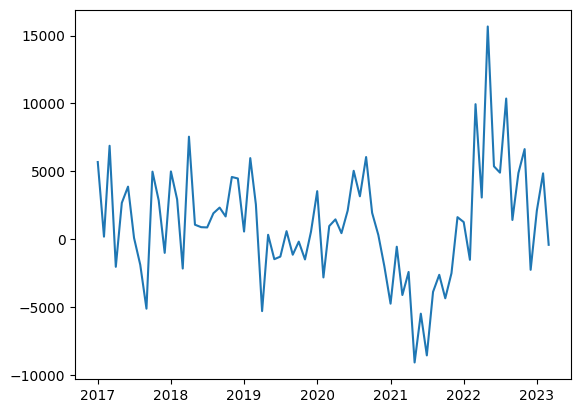

In [43]:
plt.plot(df_train['differences'])

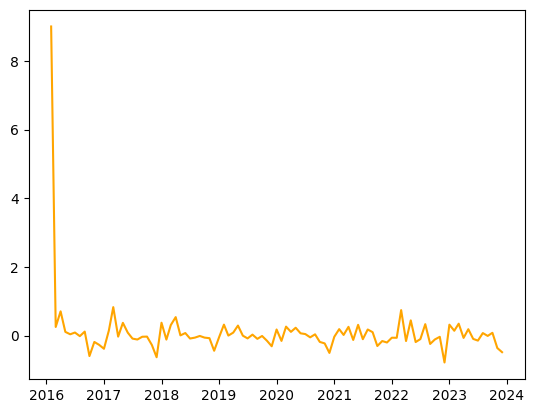

In [44]:
df_month['first_logged_diff'] = df_month['log'].diff().dropna()

plt.plot(df_month['first_logged_diff'], color='orange')
plt.show()

In [45]:
result = adfuller(df_month['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -3.8267
P-value = 0.0026


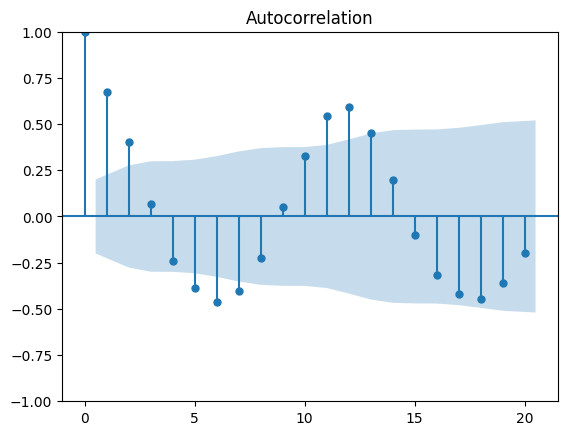

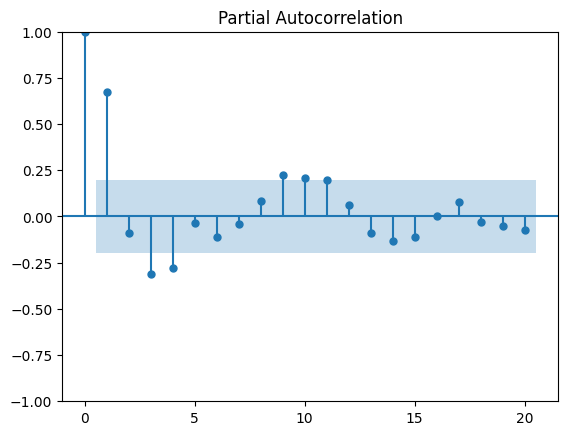

In [46]:
plot_acf(df_month[header])
plot_pacf(df_month[header])
plt.show()

In [47]:
#Mittelwertbereinigung
df_month['month'] = df_month['year-month'].dt.month
df_month['monthly_mean'] = df_month.groupby('month')['log'].transform('mean')
df_month['cleaned_by_mean'] = df_month['log'] - df_month['monthly_mean']
display(df_month)

,year-month,bruehler_straße,scaled,log,first_logged_diff,month,monthly_mean,cleaned_by_mean
year-month,,,,,,,,
2016-01-01,2016-01-01,8304,1.000000,0.000000,NaN,1,8.318925,-8.318925
2016-02-01,2016-02-01,14704,8099.552022,8.999564,8.999564,2,9.502807,-0.503243
2016-03-01,2016-03-01,16553,10439.274317,9.253330,0.253766,3,9.849263,-0.595933
2016-04-01,2016-04-01,25046,21186.305929,9.961110,0.707780,4,10.030930,-0.069820
2016-05-01,2016-05-01,26992,23648.771903,10.071066,0.109956,5,10.221226,-0.150159
...,...,...,...,...,...,...,...,...
2023-08-01,2023-08-01,29346,26627.520569,10.189701,0.075027,8,10.250489,-0.060789
2023-09-01,2023-09-01,29189,26428.852965,10.182212,-0.007489,9,10.235070,-0.052858
2023-10-01,2023-10-01,31000,28720.490107,10.265366,0.083154,10,10.085189,0.180177


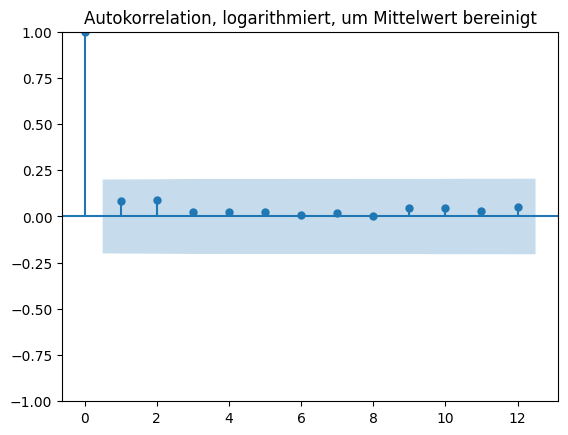

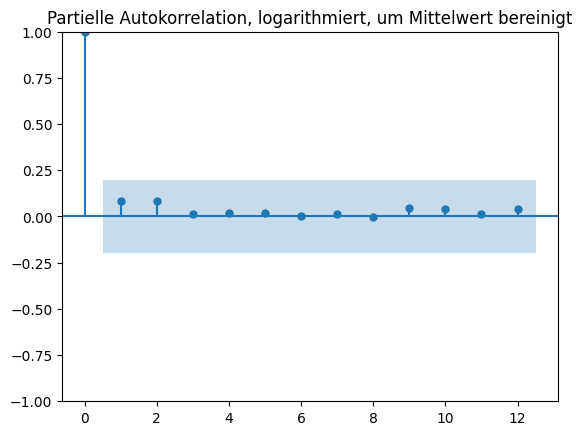

In [48]:
lags  = 12
plot_acf(df_month['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df_month['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()

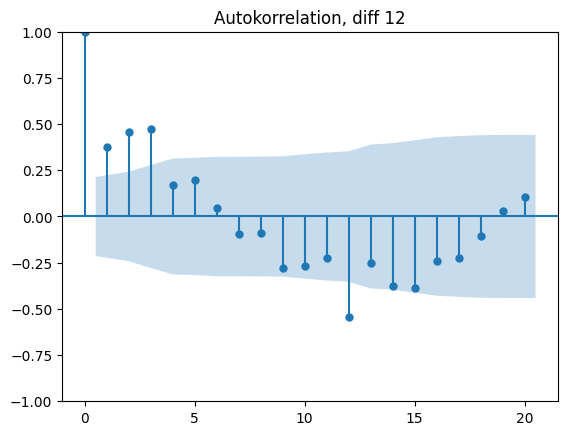

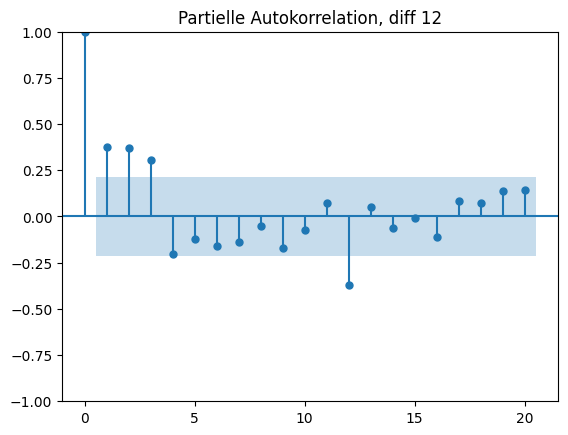

In [49]:
diffs = df_month[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [50]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df_month) * 0.9)
df_train_seas = df_month.iloc[:end_train]
df_test_seas = df_month.iloc[end_train:]

df_train_seas = df_train_seas.asfreq('MS')

seasonal = 12
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0,1], seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,12) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible st

ARIMA (0,0,0)x(0,1,0,12) LL -110.5962, AIC: 223.1923
ARIMA (0,1,0)x(0,1,0,12) LL -110.2868, AIC: 222.5735
ARIMA (1,0,0)x(0,1,1,12) LL -110.0851, AIC: 226.1703
ARIMA (1,0,0)x(0,1,2,12) LL -110.0745, AIC: 228.1490
ARIMA (1,1,0)x(0,1,2,12) LL -105.5805, AIC: 219.1609
ARIMA (0,0,1)x(0,1,2,12) LL -110.1500, AIC: 228.3000
ARIMA (0,1,1)x(0,1,2,12) LL -108.2117, AIC: 222.4233
ARIMA (0,1,1)x(2,1,0,12) LL -108.1071, AIC: 224.2142


In [51]:
print(result7.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                  log   No. Observations:                   87
Model:             SARIMAX(0, 1, 1)x(0, 1, [2], 12)   Log Likelihood                -108.212
Date:                              Sun, 09 Feb 2025   AIC                            222.423
Time:                                      22:38:23   BIC                            229.336
Sample:                                  01-01-2016   HQIC                           225.181
                                       - 03-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5213      0.062     -8.422      0.000      -0.643      -0.400
ma.S.L24      -0.05

In [52]:
start_date = '2023-04-01'
end_date = '2024-12-01'
results_final = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0, 1], seasonal)).fit()
y_pred_no_update = results_final.predict(start='2023-04-01', end='2024-12-01')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


            predicted_mean      unlogged   new_predict
2023-04-01       10.206456  27077.422897  29701.541940
2023-05-01       10.669261  43013.142081  42294.978705
2023-06-01       10.470549  35261.558550  36169.175666
2023-07-01       10.378315  32154.745895  33713.971212
2023-08-01       10.700731  44388.282431  43381.703619
2023-09-01       10.456434  34767.341157  35778.613092
2023-10-01       10.352020  31320.255948  33054.503242
2023-11-01       10.314991  30181.686284  32154.731797
2023-12-01        9.518245  13605.709326  19055.321897
2024-01-01        9.838523  18742.018312  23114.365714
2024-02-01        9.995611  21930.002929  25633.717506
2024-03-01       10.306029  29912.414329  31941.935669
2024-04-01       10.302696  29812.898745  31863.292013
2024-05-01       10.736048  45983.959835  44642.711186
2024-06-01       10.563225  38685.689768  38875.145786
2024-07-01       10.470512  35260.279576  36168.164937
2024-08-01       10.785067  48294.235955  46468.440913
2024-09-01

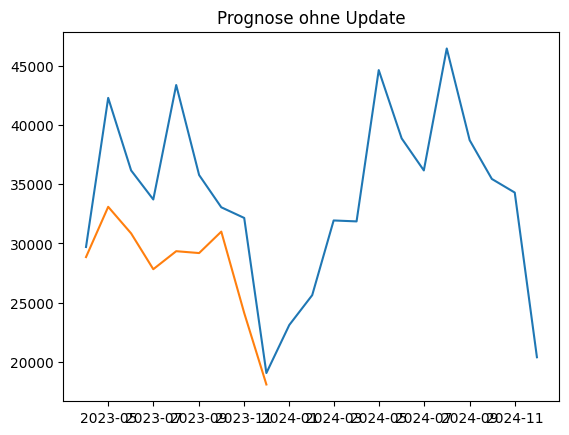

mean absolute error (mae): ARIMA: 5881.2824
mean squared error (mse): ARIMA: 50926096.4341
mean absolute percentage error (mape): ARIMA: 0.2053


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_14512\1074150843.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_14512\1074150843.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
C:\Users\caddowallace\AppData\Local\Temp\ipykern

In [53]:
plt.plot(y_pred_no_update['new_predict'])
plt.plot(df_test_seas[header])

plt.title('Prognose ohne Update')
plt.show()

plt.show()
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = y_pred_no_update.loc[start_date:end_date, 'new_predict']

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mse_arima = np.mean(np.square(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

In [54]:
start_date = '2016-01-01'
arima = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0, 1], seasonal), freq='MS')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df_month['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0, 1], seasonal), freq='MS')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start=start_date, end='2024-12-01')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])
tmp

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,predicted_mean,unlogged,final_data
2023-04-01,10.206456,27077.422897,29701.541940
2023-05-01,10.649824,42185.150090,41640.645841
2023-06-01,10.309348,30011.864224,32020.527413
2023-07-01,10.192910,26713.111606,29413.639577
2023-08-01,10.477877,35520.918835,36374.138950
2023-09-01,10.095642,24237.159105,27456.981651
2023-10-01,10.032666,22757.860128,26287.943849
2023-11-01,10.107020,24514.493762,27676.149448
2023-12-01,9.213442,10031.062914,16230.404927
2024-01-01,9.634541,15283.680325,20381.363190


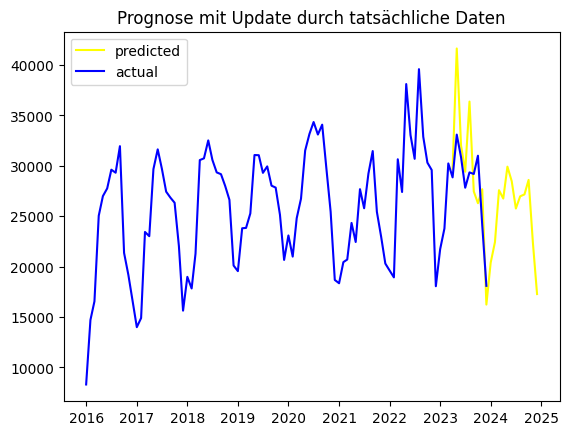

In [55]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
end_date = '2024-12-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df_month.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [56]:
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 3448.2570
mean squared error (mse): ARIMA: 18698510.5091
mean absolute percentage error (mape): ARIMA: 0.1204
